In [1]:
import pickle
import pandas as pd

In [2]:
model_path_prefix  = '../2_model_development/'
data_prefix = '../3_model_evaluation/'
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
data_types = ['All']
model_types = ['LGB']

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb


def model_confidence_analysis(model, test_data, train_data=None,
                               non_feature_cols=None):
    if non_feature_cols is None:
        non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5', 'MP_pred']

    feature_cols = [c for c in test_data.columns if c not in non_feature_cols]
    X_test = test_data[feature_cols]
    result = test_data.copy()

    # ── Random Forest ─────────────────────────────────────────────────────────
    if isinstance(model, RandomForestRegressor):
        tree_preds = np.array([tree.predict(X_test) for tree in model.estimators_])
        result['uncertainty'] = tree_preds.std(axis=0)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    elif isinstance(model, lgb.LGBMRegressor):
        if train_data is None:
            raise ValueError("train_data is required for LGB quantile confidence analysis.")

        X_train = train_data[feature_cols]
        y_train = train_data['MP']

        params = model.get_params()
        params.pop('objective', None)   # will be overridden below

        lower_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.1)
        lower_model.fit(X_train, y_train)

        upper_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.9)
        upper_model.fit(X_train, y_train)

        result['lower'] = lower_model.booster_.predict(X_test)
        result['upper'] = upper_model.booster_.predict(X_test)
        result['uncertainty'] = result['upper'] - result['lower']

    # ── XGBoost ───────────────────────────────────────────────────────────────
    elif isinstance(model, xgb.XGBRegressor):
        if train_data is None:
            raise ValueError("train_data is required for XGB quantile confidence analysis.")

        X_train = train_data[feature_cols].values
        y_train = train_data['MP'].values

        # Pinball (quantile) loss – works on all XGBoost versions
        def _pinball_obj(alpha):
            def obj(y_pred, dtrain):
                y_true = dtrain.get_label()
                error  = y_true - y_pred
                grad   = np.where(error >= 0, -alpha, 1.0 - alpha)
                hess   = np.ones_like(y_pred)
                return grad, hess
            return obj

        # Map sklearn wrapper params → native xgb params
        skl_params = model.get_params()
        n_estimators = skl_params.get('n_estimators', 100)

        _param_map = {
            'max_depth':          'max_depth',
            'learning_rate':      'eta',
            'subsample':          'subsample',
            'colsample_bytree':   'colsample_bytree',
            'colsample_bylevel':  'colsample_bylevel',
            'colsample_bynode':   'colsample_bynode',
            'min_child_weight':   'min_child_weight',
            'gamma':              'gamma',
            'reg_alpha':          'alpha',
            'reg_lambda':         'lambda',
            'n_jobs':             'nthread',
            'random_state':       'seed',
            'max_delta_step':     'max_delta_step',
            'scale_pos_weight':   'scale_pos_weight',
        }
        native_params = {'objective': 'reg:squarederror', 'verbosity': 0}
        for skl_key, xgb_key in _param_map.items():
            val = skl_params.get(skl_key)
            if val is not None:
                native_params[xgb_key] = val

        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest  = xgb.DMatrix(X_test.values)

        lower_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.1),
                                   verbose_eval=False)
        upper_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.9),
                                   verbose_eval=False)

        result['lower'] = lower_booster.predict(dtest)
        result['upper'] = upper_booster.predict(dtest)
        result['uncertainty'] = result['upper'] - result['lower']

    else:
        raise TypeError(
            f"Unsupported model type: {type(model).__name__}. "
            "Expected RandomForestRegressor, LGBMRegressor, or XGBRegressor."
        )

    return result


In [4]:
import joblib


for model_type in model_types:

    for data_type in data_types:

        print(f"Processing model: {model_type}, data type: {data_type}")

        data = pd.read_parquet(f'../0_data/processed_data/data_with_selected_features_{model_type}_{data_type}_scaled.parquet')

        if data_type != 'All':
            data = data[data[label] == data_type]

        train_df = data[data['Type'] == 'Train']
        test_df = data[data['Type'] == 'Test']

        model = joblib.load(f'{model_path_prefix}best_model_{model_type}_{data_type}.joblib')

        test_df['MP_pred'] = model.booster_.predict(test_df.drop(columns=non_feature_cols))
        test_df['AE'] = (test_df['MP'] - test_df['MP_pred']).abs()

        results = model_confidence_analysis(model=model, test_data=test_df, train_data=train_df,
                                    non_feature_cols= ['SMILES', 'MP', 'Type', 'MP_label', 'MP_pred', 'AE'])
        
        results.to_csv(f'model_confidence_results_{model_type}_{data_type}.csv', index=False)

Processing model: LGB, data type: All


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_uncertainty_vs_ae(data, model_name):

    sns.scatterplot(data=data, x='uncertainty', y='AE')
    # add correlation coefficient
    corr = data['uncertainty'].corr(data['AE'])
    plt.title(f'{model_name}: AE vs Uncertainty (corr={corr:.2f})')


    # pearson corr to check which columns in the data associated with higher uncertainty
    corr_matrix = data.drop(columns = ['SMILES', 'Type', 'MP_label']).corr()
    uncertainty_corr = corr_matrix['uncertainty'].drop('uncertainty').sort_values(ascending=False)
    # print top 10 features most correlated with uncertainty
    print("Top 10 features most correlated with uncertainty:")
    print(uncertainty_corr.head(10))

    # print top 10 features most negatively correlated with uncertainty
    print("\nTop 10 features most negatively correlated with uncertainty:")
    print(uncertainty_corr.tail(10))

    # print the mean AE and uncertainty for Ro5 vs bRo5 compounds
    for MP_label in ['H',  'L']:
        subset = data[data['MP_label'] == MP_label]
        mean_ae = subset['AE'].mean()
        mean_uncertainty = subset['uncertainty'].mean()
        print(f"MP_label={MP_label}: Mean AE = {mean_ae:.2f}, Mean Uncertainty = {mean_uncertainty:.2f}")


Plotting model: LGB, data type: All
Top 10 features most correlated with uncertainty:
upper                 0.560790
MP_pred               0.417804
MP                    0.363991
AE                    0.255193
lower                 0.205552
RDKit_RingCount       0.176348
RDKit_BCUT2D_CHGHI    0.164636
RDKit_SlogP_VSA8      0.150425
RDKit_SMR_VSA3        0.145524
MACCS_98              0.134239
Name: uncertainty, dtype: float64

Top 10 features most negatively correlated with uncertainty:
RDKit_BCUT2D_CHGLO        -0.126919
RDKit_MolLogP             -0.130319
MACCS_155                 -0.159549
RDKit_SMR_VSA5            -0.160961
RDKit_Kappa2              -0.165242
RDKit_VSA_EState7         -0.166335
RDKit_SlogP_VSA5          -0.176254
RDKit_Phi                 -0.185093
RDKit_NumRotatableBonds   -0.194615
RDKit_BCUT2D_LOGPLOW      -0.203847
Name: uncertainty, dtype: float64
MP_label=H: Mean AE = 52.84, Mean Uncertainty = 88.96
MP_label=L: Mean AE = 24.98, Mean Uncertainty = 69.05


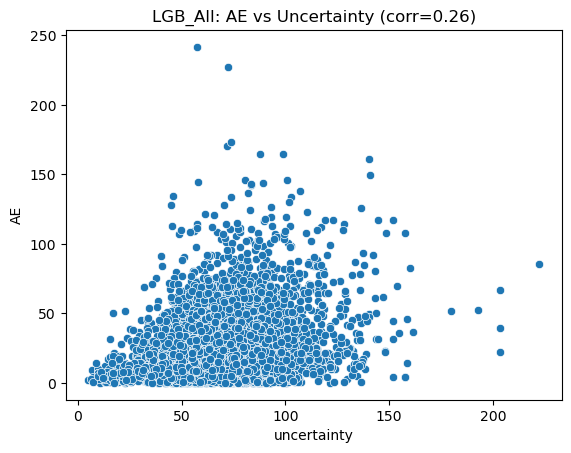

In [6]:
for model_type in model_types:
    
    for data_type in data_types:

        print(f"Plotting model: {model_type}, data type: {data_type}")

        results = pd.read_csv(f'model_confidence_results_{model_type}_{data_type}.csv')

        plot_uncertainty_vs_ae(results, f'{model_type}_{data_type}')


In [7]:
results

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,MP_pred,AE,lower,upper,uncertainty
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,202.769161,87.769161,162.833457,224.972141,62.138684
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,-0.488331,0.374209,-0.562084,-0.133569,0.908283,75.548708,28.451292,54.184674,118.722408,64.537735
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,106.923252,21.076748,62.565644,136.640794,74.075151
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,117.835232,4.835232,95.067569,151.462658,56.395089
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,23.300981,11.300981,16.027778,79.939339,63.911561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.488331,0.323579,1.779092,-0.133569,0.084641,126.424089,32.075911,99.403890,160.957581,61.553691
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,-0.488331,3.044038,-0.562084,-0.133569,0.268670,98.678745,21.321255,64.340076,119.138970,54.798894
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,39.153987,5.153987,36.742040,72.061799,35.319759
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,2.047792,-0.586923,1.779092,-0.133569,-0.346521,151.869502,30.869502,127.668893,184.380791,56.711897


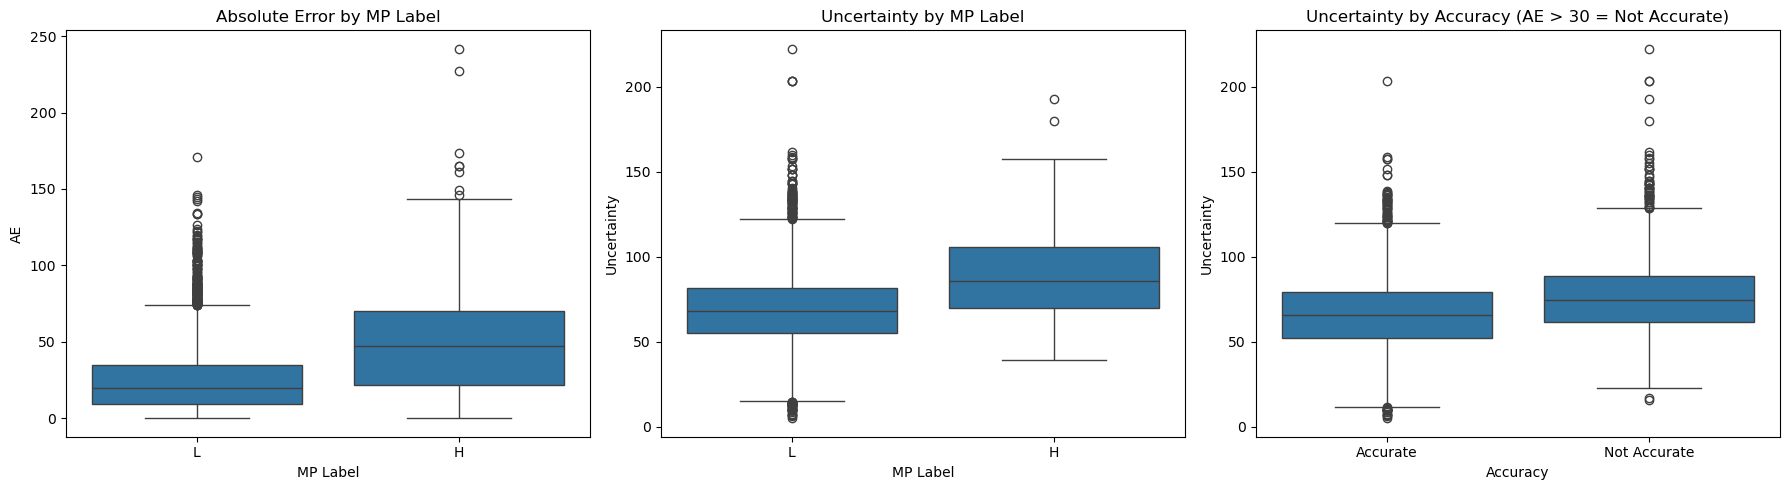

In [13]:
def plot_boxplots_by_mp_label(results, ae_threshold=30):
    df = results.copy()
    df['Accuracy'] = df['AE'].apply(lambda x: 'Not Accurate' if x > ae_threshold else 'Accurate')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.boxplot(data=df, x='MP_label', y='AE', ax=axes[0])
    axes[0].set_title('Absolute Error by MP Label')
    axes[0].set_xlabel('MP Label')
    axes[0].set_ylabel('AE')

    sns.boxplot(data=df, x='MP_label', y='uncertainty', ax=axes[1])
    axes[1].set_title('Uncertainty by MP Label')
    axes[1].set_xlabel('MP Label')
    axes[1].set_ylabel('Uncertainty')

    sns.boxplot(data=df, x='Accuracy', y='uncertainty', order=['Accurate', 'Not Accurate'], ax=axes[2])
    axes[2].set_title(f'Uncertainty by Accuracy (AE > {ae_threshold} = Not Accurate)')
    axes[2].set_xlabel('Accuracy')
    axes[2].set_ylabel('Uncertainty')

    plt.tight_layout()
    plt.show()

plot_boxplots_by_mp_label(results)


Calibration: 64.6% of true MP values fall within the 80% prediction interval [lower, upper]
  (Expected ~80% for a well-calibrated model)

Stratified performance by uncertainty bin:
uncertainty_bin  count  mean_uncertainty       MAE  pct_not_accurate
             Q1   1034         41.315932 18.243101         17.214700
             Q2   1033         58.310606 23.842639         29.719264
             Q3   1033         68.651884 25.859591         32.623427
             Q4   1033         79.674412 29.199226         40.271055
             Q5   1033        102.404723 34.877503         47.047435



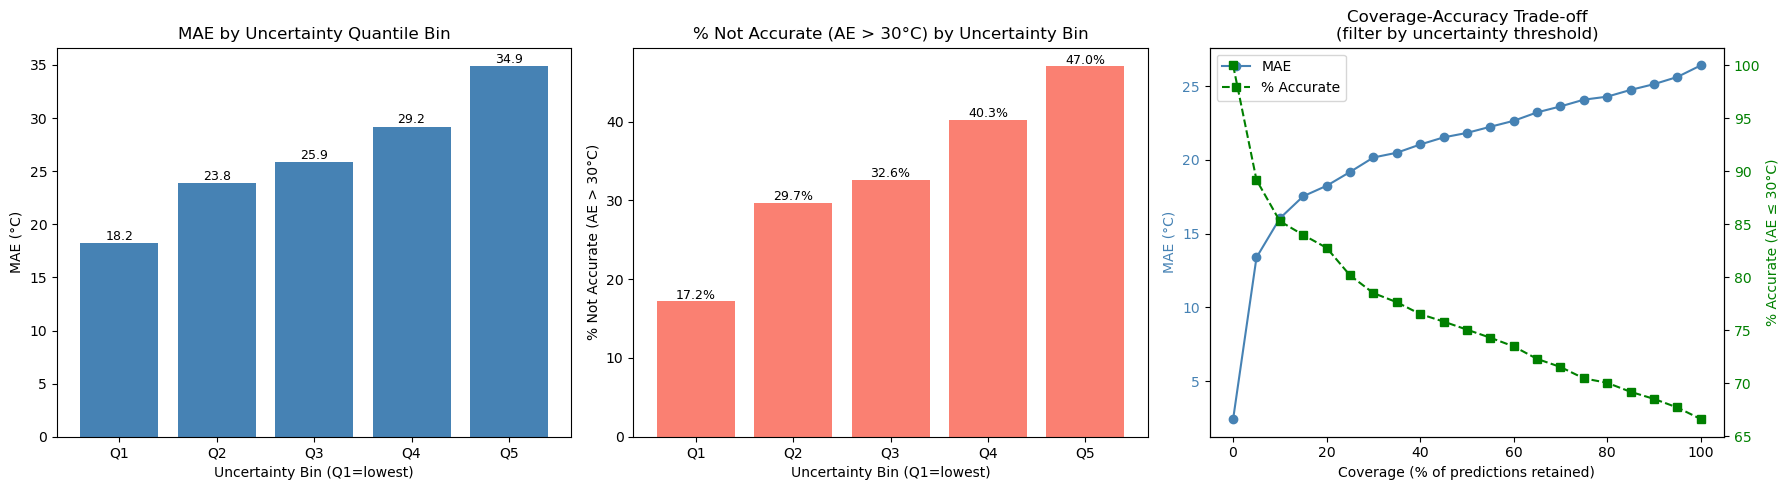

In [14]:
def analyze_uncertainty_trust(results, ae_threshold=30, n_bins=5):
    """
    Analyze how well uncertainty predicts trustworthiness of predictions.

    1. Calibration: % of true MP values inside [lower, upper] interval
    2. Stratified MAE by uncertainty quantile bin
    3. Coverage-accuracy trade-off: as high-uncertainty predictions are filtered,
       how does MAE and coverage change
    """
    df = results.copy()
    df['Accuracy'] = df['AE'].apply(lambda x: 'Not Accurate' if x > ae_threshold else 'Accurate')

    # ── 1. Calibration ────────────────────────────────────────────────────────
    if 'lower' in df.columns and 'upper' in df.columns:
        inside = ((df['MP'] >= df['lower']) & (df['MP'] <= df['upper'])).mean()
        print(f"Calibration: {inside*100:.1f}% of true MP values fall within the 80% prediction interval [lower, upper]")
        print(f"  (Expected ~80% for a well-calibrated model)\n")
    else:
        print("Note: 'lower'/'upper' columns not found — skipping calibration check.\n")

    # ── 2. Stratified MAE by uncertainty quantile bin ─────────────────────────
    df['uncertainty_bin'] = pd.qcut(df['uncertainty'], q=n_bins,
                                    labels=[f'Q{i+1}' for i in range(n_bins)])
    bin_stats = (df.groupby('uncertainty_bin', observed=True)
                   .agg(
                       count=('AE', 'size'),
                       mean_uncertainty=('uncertainty', 'mean'),
                       MAE=('AE', 'mean'),
                       pct_not_accurate=('Accuracy', lambda x: (x == 'Not Accurate').mean() * 100)
                   )
                   .reset_index())
    print("Stratified performance by uncertainty bin:")
    print(bin_stats.to_string(index=False))
    print()

    # ── 3. Coverage-accuracy trade-off ────────────────────────────────────────
    thresholds = np.percentile(df['uncertainty'], np.arange(0, 101, 5))
    thresholds = np.unique(thresholds)

    coverages, maes, pct_accurate = [], [], []
    for t in thresholds:
        subset = df[df['uncertainty'] <= t]
        if len(subset) == 0:
            continue
        coverages.append(len(subset) / len(df) * 100)
        maes.append(subset['AE'].mean())
        pct_accurate.append((subset['Accuracy'] == 'Accurate').mean() * 100)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 2a: MAE vs uncertainty bin
    axes[0].bar(bin_stats['uncertainty_bin'].astype(str), bin_stats['MAE'], color='steelblue')
    axes[0].set_xlabel('Uncertainty Bin (Q1=lowest)')
    axes[0].set_ylabel('MAE (°C)')
    axes[0].set_title('MAE by Uncertainty Quantile Bin')
    for i, row in bin_stats.iterrows():
        axes[0].text(i, row['MAE'] + 0.3, f"{row['MAE']:.1f}", ha='center', fontsize=9)

    # Plot 2b: % Not Accurate vs uncertainty bin
    axes[1].bar(bin_stats['uncertainty_bin'].astype(str), bin_stats['pct_not_accurate'], color='salmon')
    axes[1].set_xlabel('Uncertainty Bin (Q1=lowest)')
    axes[1].set_ylabel(f'% Not Accurate (AE > {ae_threshold}°C)')
    axes[1].set_title(f'% Not Accurate (AE > {ae_threshold}°C) by Uncertainty Bin')
    for i, row in bin_stats.iterrows():
        axes[1].text(i, row['pct_not_accurate'] + 0.3, f"{row['pct_not_accurate']:.1f}%", ha='center', fontsize=9)

    # Plot 2c: Coverage vs MAE trade-off
    ax2 = axes[2].twinx()
    axes[2].plot(coverages, maes, 'o-', color='steelblue', label='MAE')
    ax2.plot(coverages, pct_accurate, 's--', color='green', label='% Accurate')
    axes[2].set_xlabel('Coverage (% of predictions retained)')
    axes[2].set_ylabel('MAE (°C)', color='steelblue')
    ax2.set_ylabel(f'% Accurate (AE ≤ {ae_threshold}°C)', color='green')
    axes[2].set_title('Coverage-Accuracy Trade-off\n(filter by uncertainty threshold)')
    axes[2].tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='green')
    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

analyze_uncertainty_trust(results)
